Notebook Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


Load Data

In [4]:
form = pd.read_csv("../data/processed/form_features_2025.csv")
quali = pd.read_csv("../data/raw/qualifying_results_2025.csv")

# Merge qualifying context (light merge, no leakage)
df = form.merge(
    quali[[
        "season", "round", "DriverNumber",
        "qualifying_position", "delta_to_pole", "made_q3"
    ]],
    on=["season", "round", "DriverNumber"],
    how="left"
)

df.head()


,season,round,race_name,DriverNumber,Abbreviation,FullName,TeamName,finish_position,grid_position,positions_gained,...,drv_avg_points_l5,drv_avg_pos_gained_l5,drv_finish_std_l5,drv_dnf_rate_l5,team_avg_finish_l5,team_avg_points_l5,team_avg_pos_gained_l5,qualifying_position,delta_to_pole,made_q3
0,2025,1,Australian Grand Prix,1,VER,Max Verstappen,Red Bull Racing,2.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.385,1
1,2025,1,Australian Grand Prix,4,NOR,Lando Norris,McLaren,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.000,1
2,2025,1,Australian Grand Prix,5,BOR,Gabriel Bortoleto,Kick Sauber,16.0,15.0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,1.420,0
3,2025,1,Australian Grand Prix,6,HAD,Isack Hadjar,Racing Bulls,20.0,11.0,-9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,1.079,0
4,2025,1,Australian Grand Prix,7,DOO,Jack Doohan,Alpine,19.0,14.0,-5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,1.219,0


Data Sanity Checks

In [5]:
df.isna().mean().sort_values(ascending=False).head(10)


drv_avg_finish_l5         0.219207
drv_avg_pos_gained_l5     0.219207
drv_dnf_rate_l5           0.219207
drv_finish_std_l5         0.219207
drv_avg_points_l5         0.219207
team_avg_finish_l5        0.104384
team_avg_points_l5        0.104384
team_avg_pos_gained_l5    0.104384
delta_to_pole             0.016701
qualifying_position       0.002088
dtype: float64

📊 CORE ANALYSES (HIGH SIGNAL ONLY)

1️⃣ Does Driver Form Correlate With Finish?

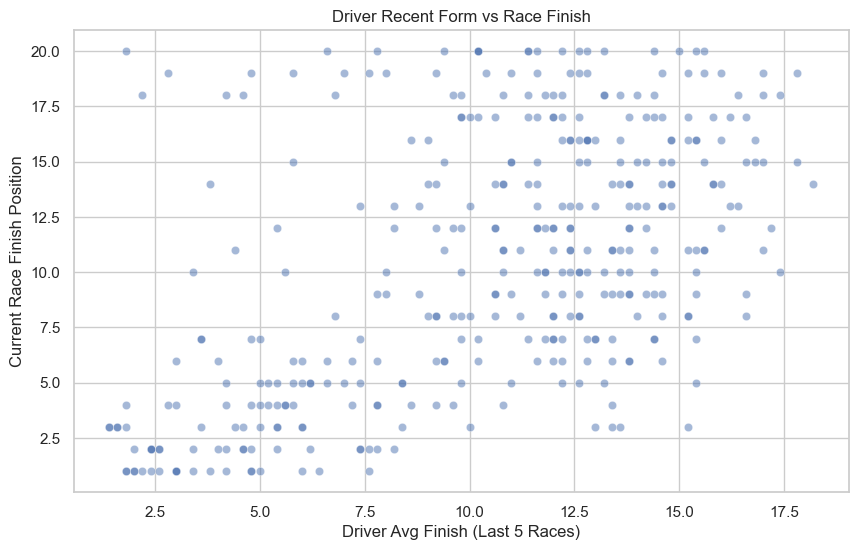

In [6]:
sns.scatterplot(
    data=df,
    x="drv_avg_finish_l5",
    y="finish_position",
    alpha=0.5
)
plt.xlabel("Driver Avg Finish (Last 5 Races)")
plt.ylabel("Current Race Finish Position")
plt.title("Driver Recent Form vs Race Finish")
plt.show()


2️⃣ Consistency vs Performance

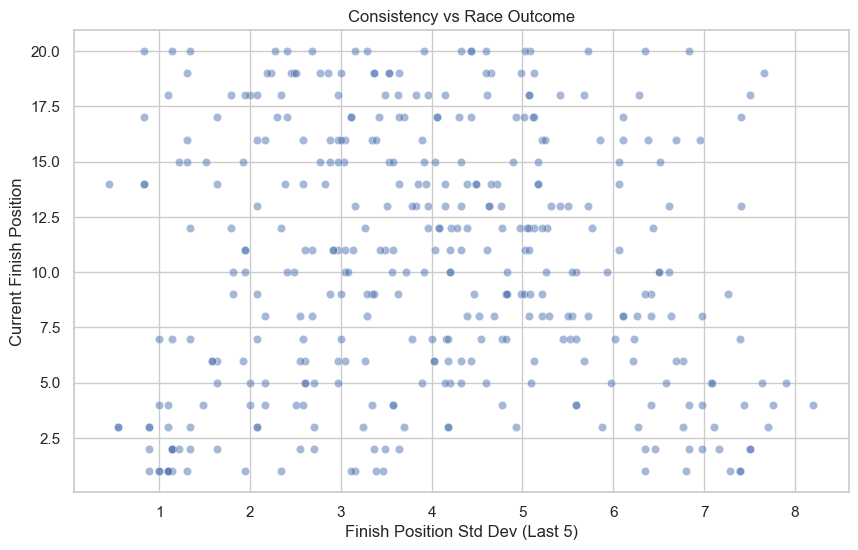

In [7]:
sns.scatterplot(
    data=df,
    x="drv_finish_std_l5",
    y="finish_position",
    alpha=0.5
)
plt.xlabel("Finish Position Std Dev (Last 5)")
plt.ylabel("Current Finish Position")
plt.title("Consistency vs Race Outcome")
plt.show()


3️⃣ Positions Gained Momentum

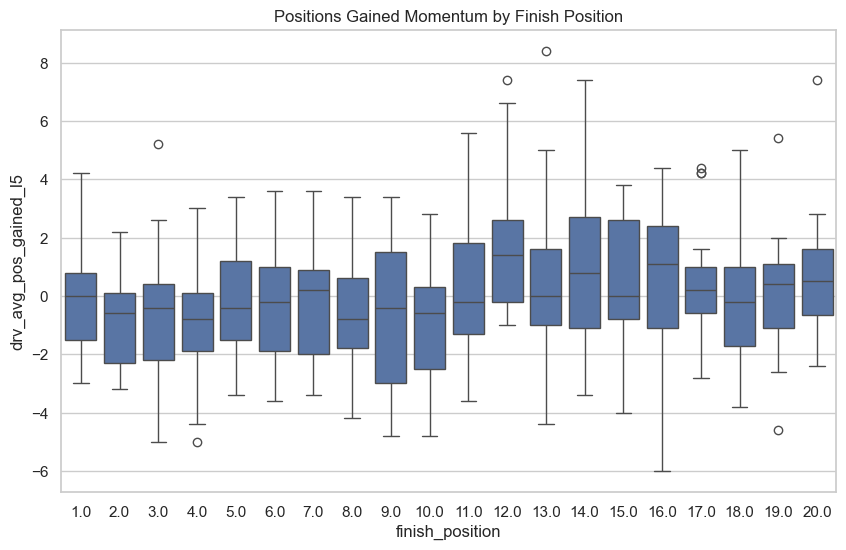

In [8]:
sns.boxplot(
    data=df,
    x="finish_position",
    y="drv_avg_pos_gained_l5"
)
plt.title("Positions Gained Momentum by Finish Position")
plt.show()


4️⃣ Team Momentum Matters?

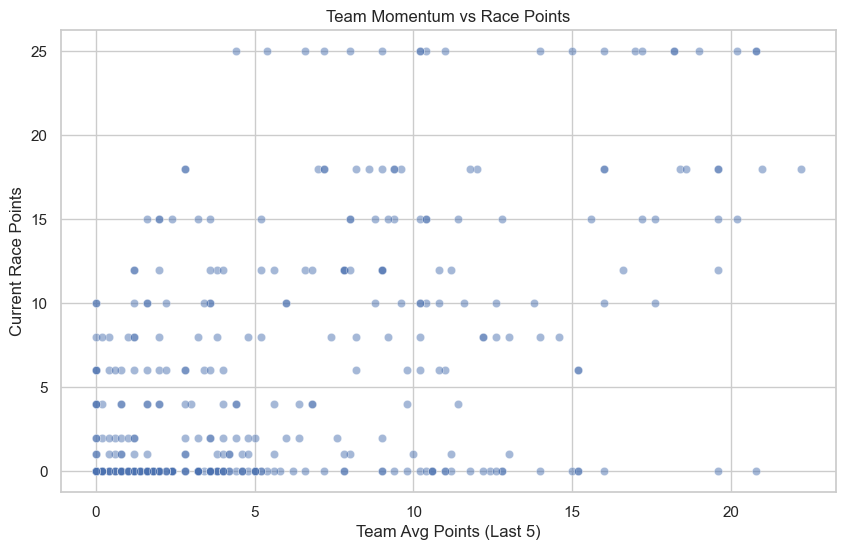

In [9]:
sns.scatterplot(
    data=df,
    x="team_avg_points_l5",
    y="Points",
    alpha=0.5
)
plt.xlabel("Team Avg Points (Last 5)")
plt.ylabel("Current Race Points")
plt.title("Team Momentum vs Race Points")
plt.show()


5️⃣ Qualifying Context Check

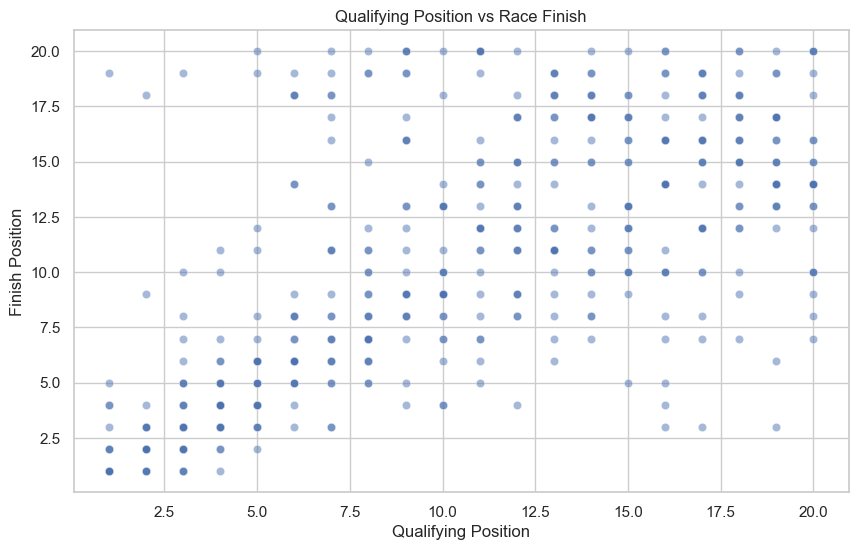

In [10]:
sns.scatterplot(
    data=df,
    x="qualifying_position",
    y="finish_position",
    alpha=0.5
)
plt.title("Qualifying Position vs Race Finish")
plt.xlabel("Qualifying Position")
plt.ylabel("Finish Position")
plt.show()


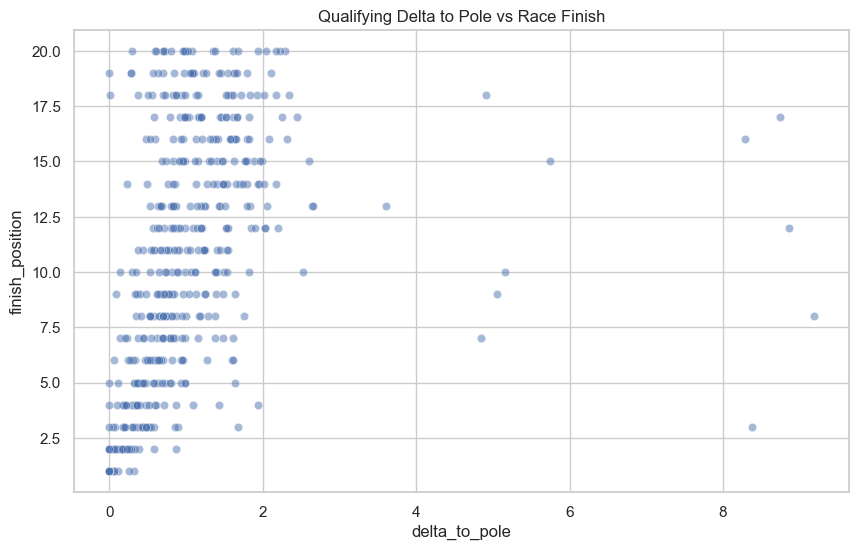

In [11]:
sns.scatterplot(
    data=df,
    x="delta_to_pole",
    y="finish_position",
    alpha=0.5
)
plt.title("Qualifying Delta to Pole vs Race Finish")
plt.show()


6️⃣ Correlation Heatmap (FINAL PLOT ONLY)

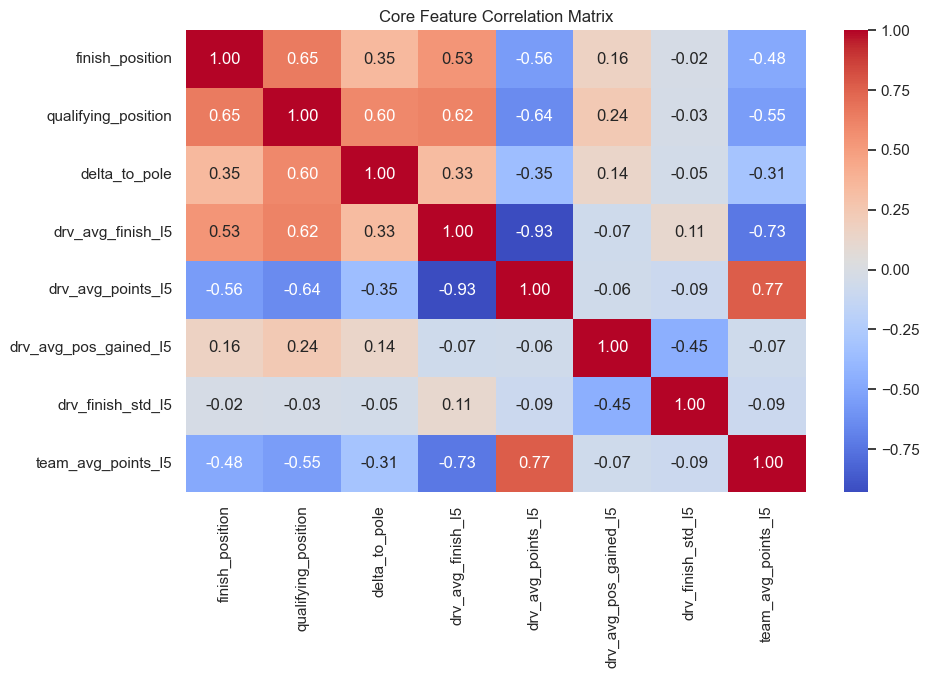

In [12]:
features = [
    "finish_position",
    "qualifying_position",
    "delta_to_pole",
    "drv_avg_finish_l5",
    "drv_avg_points_l5",
    "drv_avg_pos_gained_l5",
    "drv_finish_std_l5",
    "team_avg_points_l5",
]

corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Core Feature Correlation Matrix")
plt.show()


# 🧠 Key Insights from 2025 Form EDA

This exploratory analysis was designed to answer **specific, domain-driven questions** about Formula 1 performance dynamics in the 2025 season.  
Each visualization was intentional and aimed at validating whether the engineered features capture **meaningful racing intelligence rather than noise**.

---

## 1️⃣ Does Recent Driver Form Correlate with Race Finish?

### Observation
The scatter plot of **driver average finish over the last 5 races** versus **current race finish position** shows a clear positive relationship, although with natural dispersion.

### Why this matters
Formula 1 performance is not static. Drivers go through:
- confidence phases,
- car development cycles,
- setup adaptations,
- mental momentum changes.

Recent form captures these **short-term performance dynamics**, which season-long averages fail to represent.

### Insight gained
- Drivers with better recent finishing averages tend to finish higher again.
- The relationship is noisy (as expected in racing), but **directionally strong**.
- This confirms that recent form is **predictive, not redundant**.

### Positives for the project
- Justifies using **rolling window features** instead of static historical statistics.
- Validates the decision to **avoid data leakage** by using only past races.
- Supports a **time-aware modeling approach** over naïve averages.

---

## 2️⃣ Does Driver Consistency Influence Outcomes?

### Observation
The plot of **finish position standard deviation (last 5 races)** versus **current finish position** shows that drivers with lower variability tend to cluster toward better race results.

### Why this matters
Consistency reflects:
- reliability,
- error avoidance,
- ability to extract performance across different tracks and conditions.

In Formula 1, finishing consistently P6–P8 can be more valuable than occasional podiums mixed with DNFs.

### Insight gained
- High-variance drivers are **less predictable and riskier**.
- Low-variance drivers tend to deliver **stable performance floors**.
- Consistency is an **independent signal**, not captured by average finish alone.

### Positives for the project
- Enables later modeling of **uncertainty or confidence**, not just point predictions.
- Allows differentiation between *fast but erratic* and *consistently strong* drivers.
- Adds **interpretability**, something most GitHub F1 projects lack.

---

## 3️⃣ Does Positions Gained Capture Race Execution Quality?

### Observation
The boxplot comparing **rolling average positions gained** against **finishing positions** shows that:
- top finishers often have **positive position-gain momentum**,
- midfield drivers who consistently gain places outperform grid-based expectations.

### Why this matters
Qualifying speed ≠ race execution.

Positions gained captures:
- overtaking ability,
- tyre management,
- strategy execution,
- adaptability during safety cars and race incidents.

### Insight gained
- Drivers who consistently gain positions tend to outperform their qualifying baseline.
- This metric isolates **race craft**, not just car pace.
- It explains why some drivers finish well even without top qualifying positions.

### Positives for the project
- Adds a **race-specific intelligence feature**, not just session results.
- Helps avoid over-reliance on qualifying metrics.
- Strengthens analytical depth beyond typical F1 ML projects.

---

## 4️⃣ Does Team Momentum Affect Individual Driver Results?

### Observation
The relationship between **team average points over the last 5 races** and **current race points** shows a visible upward trend.

### Why this matters
Formula 1 is fundamentally a **team sport**, involving:
- car upgrades,
- reliability fixes,
- strategic decisions,
- pit-stop performance.

Even elite drivers are constrained by team performance.

### Insight gained
- Drivers from teams with strong recent momentum are more likely to score points.
- Team-level trends propagate to individual outcomes.
- Ignoring team context leads to **incomplete driver evaluation**.

### Positives for the project
- Justifies **team-level features** alongside driver-level features.
- Prevents misleading conclusions when analyzing drivers in isolation.
- Aligns the model with **real-world F1 dynamics**.

---

## 5️⃣ Qualifying Position vs Qualifying Delta: Which Matters More?

### Observation
- **Qualifying position vs finish position** shows correlation but with significant spread.
- **Delta to pole vs finish position** exhibits a cleaner, more continuous relationship.

### Why this matters
Qualifying position is **ordinal** and affected by:
- grid penalties,
- traffic,
- track evolution.

Delta to pole captures **absolute pace**, independent of grid artifacts.

### Insight gained
- Absolute pace metrics are more informative than rank alone.
- Two drivers qualifying P6 may have very different underlying performance.
- Delta-based features preserve **performance granularity**.

### Positives for the project
- Justifies using **`delta_to_pole`** instead of only qualifying position.
- Improves generalization across tracks and conditions.
- Elevates feature design above basic leaderboard-based approaches.

---

## 6️⃣ Overall Feature Relationships (Correlation Matrix)

### Observation
The correlation heatmap shows:
- strong links between recent form features and race outcomes,
- complementary signals rather than redundant ones,
- no single feature dominating completely.

### Why this matters
A strong feature set should:
- capture different aspects of performance,
- avoid extreme multicollinearity,
- provide multiple explanatory angles.

### Insight gained
- Driver form, team momentum, race craft, and qualifying pace all contribute.
- The system is **multi-factor**, not driven by a single metric.
- This supports **multivariate or ensemble modeling approaches**.

### Positives for the project
- Confirms the feature engineering strategy is **balanced**.
- Reduces risk of overfitting to one signal.
- Sets a strong foundation for both baseline and ML models.

---

## 🏁 Final EDA Conclusion

This EDA confirms that:
- **Recent form matters** and should be modeled explicitly.
- **Consistency and momentum** provide valuable predictive context.
- **Race execution** is a distinct and important dimension of performance.
- **Team context** meaningfully shapes driver outcomes.
- **Delta-based qualifying metrics** outperform rank-based ones.

Most importantly, the analysis validates that the engineered features are:
- statistically meaningful,
- domain-aligned,
- interpretable,
- and suitable for robust modeling.

This positions the project as a **serious statistical F1 analysis framework**, not just a prediction demo.

